# Comment Category Prediction Challenge

In [80]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


## Load the datasets

In [81]:
import pandas as pd
import numpy as np

train = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv")

In [82]:
# print("Train data: ",train.head())
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [83]:
sample.sample(10)

,ID,label
78028,78029,0
3655,3656,0
46018,46019,0
91323,91324,0
57518,57519,0
91278,91279,0
6871,6872,0
94816,94817,0
98792,98793,0
30873,30874,0


In [84]:
print("Train data size: ", train.shape)
print("Test data size: ", test.shape)
print("Sample submission data size: ", sample.shape)

Train data size:  (198000, 15)
Test data size:  (102000, 14)
Sample submission data size:  (102000, 2)


In [85]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


## Appendix - Milestones

In [86]:
train_df = train.copy()
test_df = test.copy()
sample_df = sample.copy()

### Milestone - 1

In [87]:
# train_df.isna().sum()

In [88]:
# train_df[train["label"] == '0'].sum()

In [89]:
# train_df["label"].unique()

In [90]:
# train_df["label"].value_counts(normalize=True) * 100

In [91]:
# train_df["upvote"].median()
# train_df[["upvote", "downvote", "if_1", "if_2"]].max()
# train_df["if_2"].min()

### Milestone - 2

In [92]:
##### Milestone - 2
## Convert the created_date column into datetime objects.
# Q2
# train_df["created_date"] = pd.to_datetime(train_df["created_date"])
# train_df["month"] = train_df["created_date"].dt.month_name().str.lower()
# train_df["month"].value_counts()

In [93]:
# Q3
'''Create a new feature called total_emoticons by calculating the sum of emoticon_1,
emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature
across the entire dataset?'''

# train_df["total_emoticons"] = (train_df["emoticon_1"] + train_df["emoticon_2"] + train_df["emoticon_3"])
# train_df["total_emoticons"].max()

'Create a new feature called total_emoticons by calculating the sum of emoticon_1,\nemoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature\nacross the entire dataset?'

In [94]:
## Q4
'''Calculate the median character length (including spaces) of the comment column for all entries 
where label is equal to 3. (Note: Treat any missing comments as empty strings).'''

# train_df["comment"] = train_df["comment"].fillna("")
# train_df["char_len"] = train_df["comment"].apply(len)
# median_len = train_df.loc[train_df["label"] == 3, "char_len"].median()
# median_len

'Calculate the median character length (including spaces) of the comment column for all entries \nwhere label is equal to 3. (Note: Treat any missing comments as empty strings).'

In [95]:
# ## Q5
# min_val = train_df["upvote"].min()
# max_val = train_df["upvote"].max()
# scaled_10 = (10 - min_val) / (max_val - min_val)
# scaled_10

In [96]:
# ## Q6
# train_df["word_count"] = train_df["comment"].apply(lambda x: len(x.split()))
# avg_wc = train_df.loc[train_df["label"] == 1, "word_count"].mean()
# round(avg_wc, 2)

In [97]:
## Q7
# trump_count = train_df["comment"].str.contains("Trump", case=False, na=False).sum()
# trump_count

In [98]:
# ## Q8
# stop_words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as',
#               'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from',
#               'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are',
#               'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
#               'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their',
#               'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which',
#               'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']


# # Remove Punctuations
# import string

# text = train_df.loc[0, "comment"]
# text = text.translate(str.maketrans('', '', string.punctuation))


# # Tokenize + remove stopwords
# words = text.lower().split()
# filtered_words = [w for w in words if w not in stop_words]
# len(filtered_words)


In [99]:
## Q9
## Total Unique Tokens in Dataset
## Lowercase + whitespace tokenization:

# train_df["comment"] = train_df["comment"].fillna("").str.lower()
# tokens = train_df["comment"].apply(lambda x: x.split())

# unique_tokens = set()

# for row in tokens:
#     unique_tokens.update(row)


# len(unique_tokens)

In [100]:
## Q10
## TF-IDF Feature Count
## Apply exactly:

# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     stop_words="english",
#     min_df=5,
#     ngram_range=(1,2)
# )

# X = tfidf.fit_transform(train_df["comment"])

# X.shape

### Milestone - 3

In [101]:
##Q1
## Split dataset into X_train and X_val

# from sklearn.model_selection import train_test_split

# X = train_df.drop("label", axis=1)
# y = train_df["label"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train.shape, X_val.shape

In [102]:
## Q2
# X_train["created_date"] = pd.to_datetime(X_train["created_date"])

# X_train["month"] = X_train["created_date"].dt.month_name().str.lower()
# X_train["year"] = X_train["created_date"].dt.year
# X_train["day"] = X_train["created_date"].dt.day

# X_train["month"].value_counts()

In [103]:
## Q3
## Impute + One Hot Encode
## We only encode:religion, gender, race

## First impute

# cat_cols = ["religion", "gender", "race"]

# X_train[cat_cols] = X_train[cat_cols].fillna("none")
# X_val[cat_cols] = X_val[cat_cols].fillna("none")

In [104]:
## Q3 OneHotEncoding

# from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# encoded_train = encoder.fit_transform(X_train[cat_cols])
# encoded_val = encoder.transform(X_val[cat_cols])

# encoded_train_df = pd.DataFrame(
#     encoded_train,
#     columns=encoder.get_feature_names_out(cat_cols),
#     index=X_train.index
# )

# encoded_val_df = pd.DataFrame(
#     encoded_val,
#     columns=encoder.get_feature_names_out(cat_cols),
#     index=X_val.index
# )

In [105]:
## Drop original categorical columns and concatenate
# X_train = X_train.drop(columns=cat_cols)
# X_val = X_val.drop(columns=cat_cols)

# X_train = pd.concat([X_train, encoded_train_df], axis=1)
# X_val = pd.concat([X_val, encoded_val_df], axis=1)

# X_train.shape

In [106]:
## Q4 CountVectorizer Sum for Row Index 1
# from sklearn.feature_extraction.text import CountVectorizer

# vectorizer = CountVectorizer()

# X_train_counts = vectorizer.fit_transform(X_train["comment"])
# X_val_counts = vectorizer.transform(X_val["comment"])

# X_train_counts[1].sum()

In [107]:
## Q5 Convert Disability to Int + Sum
# X_train["disability"] = X_train["disability"].astype(int)
# X_val["disability"] = X_val["disability"].astype(int)

# X_train["disability"].sum() + X_val["disability"].sum()

In [108]:
## Q6 StandardScaler — Number of Features Seen
## First drop datetime columns

# X_train = X_train.drop(columns=["created_date"])
# X_val = X_val.drop(columns=["created_date"])


# ## Now select numeric features only:

# from sklearn.preprocessing import StandardScaler

# num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# scaler = StandardScaler()
# scaler.fit(X_train[num_cols])

# scaler.n_features_in_

In [109]:
### Q7 & Q8 
### Step 0 — Split First (Very Important)

# from sklearn.model_selection import train_test_split

# X = train_df.drop("label", axis=1)
# y = train_df["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )

In [110]:
## Step 1 — Impute Missing Values (Fit ONLY on X_train)
## We must impute BEFORE feature engineering.

# from sklearn.impute import SimpleImputer
# import numpy as np
# import pandas as pd

# # Separate numeric & categorical
# num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
# cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns

# # Numeric imputer
# num_imputer = SimpleImputer(strategy="median")

# X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
# X_val[num_cols] = num_imputer.transform(X_val[num_cols])

# # Categorical imputer
# cat_imputer = SimpleImputer(strategy="most_frequent")

# X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
# X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])

In [111]:
## Ensure No Negative Values
# X_train[num_cols] = np.abs(X_train[num_cols])
# X_val[num_cols] = np.abs(X_val[num_cols])

# ## Step 2 — Convert created_date
# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# X_val["created_date"] = pd.to_datetime(X_val["created_date"])

# for df in [X_train, X_val]:
#     df["day"] = df["created_date"].dt.day
#     df["month"] = df["created_date"].dt.month
#     df["year"] = df["created_date"].dt.year

# X_train = X_train.drop(columns=["created_date"])
# X_val = X_val.drop(columns=["created_date"])

In [112]:
## Step 3 — TF-IDF on comment
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(stop_words="english")

# X_train_text = tfidf.fit_transform(X_train["comment"])
# X_val_text = tfidf.transform(X_val["comment"])

In [113]:
## Drop original comment column:

# X_train = X_train.drop(columns=["comment"])
# X_val = X_val.drop(columns=["comment"])

# ## Step 4 — One Hot Encode Categorical Features
# from sklearn.preprocessing import OneHotEncoder

# categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns

# encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# X_train_cat = encoder.fit_transform(X_train[categorical_cols])
# X_val_cat = encoder.transform(X_val[categorical_cols])


# ## Drop original categorical columns:

# X_train = X_train.drop(columns=categorical_cols)
# X_val = X_val.drop(columns=categorical_cols)

In [114]:
## Combine All Features
# from scipy.sparse import hstack

# X_train_final = hstack([
#     X_train.values,
#     X_train_cat,
#     X_train_text
# ])

# X_val_final = hstack([
#     X_val.values,
#     X_val_cat,
#     X_val_text
# ])

In [115]:
## Step 5 — Train Multinomial Naive Bayes
## MultinomialNB requires non-negative inputs — which we ensured.

# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score

# nb = MultinomialNB()

# nb.fit(X_train_final, y_train)

# train_preds = nb.predict(X_train_final)
# val_preds = nb.predict(X_val_final)

# train_f1 = f1_score(y_train, train_preds, average="macro")
# val_f1 = f1_score(y_val, val_preds, average="macro")

# print("Train Macro F1:", train_f1)
# print("Validation Macro F1:", val_f1)

In [116]:
###### Q9 & Q10

# train_df = train.copy()
# test_df = test.copy()

# ## Split First
# from sklearn.model_selection import train_test_split

# X = train_df.drop("label", axis=1)
# y = train_df["label"]

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )

In [117]:
### Impute Missing Values (Fit ONLY on X_train)
# from sklearn.impute import SimpleImputer
# import numpy as np
# import pandas as pd

# # Separate numeric & categorical
# num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
# cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns

# # Numeric imputation
# num_imputer = SimpleImputer(strategy="median")
# X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
# X_val[num_cols] = num_imputer.transform(X_val[num_cols])

# # Categorical imputation
# cat_imputer = SimpleImputer(strategy="most_frequent")
# X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
# X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])

In [118]:
### Ensure No Negative Values
# X_train[num_cols] = np.abs(X_train[num_cols])
# X_val[num_cols] = np.abs(X_val[num_cols])


### 1) Convert created_date -> day, month, year
# X_train["created_date"] = pd.to_datetime(X_train["created_date"])
# X_val["created_date"] = pd.to_datetime(X_val["created_date"])

# for df in [X_train, X_val]:
#     df["day"] = df["created_date"].dt.day
#     df["month"] = df["created_date"].dt.month
#     df["year"] = df["created_date"].dt.year

# X_train = X_train.drop(columns=["created_date"])
# X_val = X_val.drop(columns=["created_date"])

In [119]:
### 2) Create is_weekend Feature
# for df in [X_train, X_val]:
#     df["is_weekend"] = df["month"]  # temporary

### That’s wrong — we must use weekday from datetime BEFORE dropping.
### Correct way (replace above block with this):

# X_train["created_date"] = pd.to_datetime(train_df.loc[X_train.index, "created_date"])
# X_val["created_date"] = pd.to_datetime(train_df.loc[X_val.index, "created_date"])

# for df in [X_train, X_val]:
#     df["day"] = df["created_date"].dt.day
#     df["month"] = df["created_date"].dt.month
#     df["year"] = df["created_date"].dt.year
#     df["is_weekend"] = df["created_date"].dt.weekday.isin([5,6]).astype(int)

# X_train = X_train.drop(columns=["created_date"])
# X_val = X_val.drop(columns=["created_date"])

In [120]:
## 3) TF-IDF on comment
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(stop_words="english")

# X_train_text = tfidf.fit_transform(X_train["comment"])
# X_val_text = tfidf.transform(X_val["comment"])

# X_train = X_train.drop(columns=["comment"])
# X_val = X_val.drop(columns=["comment"])

In [121]:
## 4) OneHotEncode All Categorical Features (Including is_weekend)
### First identify categorical:

# categorical_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

# # Add is_weekend explicitly if not included
# if "is_weekend" in X_train.columns:
#     categorical_cols.append("is_weekend")

# ### Now encode:
# from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# X_train_cat = encoder.fit_transform(X_train[categorical_cols])
# X_val_cat = encoder.transform(X_val[categorical_cols])

# X_train = X_train.drop(columns=categorical_cols)
# X_val = X_val.drop(columns=categorical_cols)

In [122]:
### Combine All Features
# from scipy.sparse import hstack

# X_train_final = hstack([
#     X_train.values,
#     X_train_cat,
#     X_train_text
# ])

# X_val_final = hstack([
#     X_val.values,
#     X_val_cat,
#     X_val_text
# ])

In [123]:
### Train MultinomialNB
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score

# nb = MultinomialNB()
# nb.fit(X_train_final, y_train)

# train_preds = nb.predict(X_train_final)
# val_preds = nb.predict(X_val_final)

# train_f1 = f1_score(y_train, train_preds, average="macro")
# val_f1 = f1_score(y_val, val_preds, average="macro")

# print("Train Macro F1:", round(train_f1, 4))
# print("Validation Macro F1:", round(val_f1, 4))

In [124]:
# train_df.head()

In [125]:
# X_train.columns

## EDA

In [126]:
print("Train data size: ", train.shape)
print("Test data size: ", test.shape)
print("Sample submission data size: ", sample.shape)

Train data size:  (198000, 15)
Test data size:  (102000, 14)
Sample submission data size:  (102000, 2)


In [127]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [128]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


### Target variable analysis

In [129]:
print(train["label"].value_counts())
print(train["label"].value_counts(normalize=True) * 100)   ## proportion of each label in percent

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64
label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64


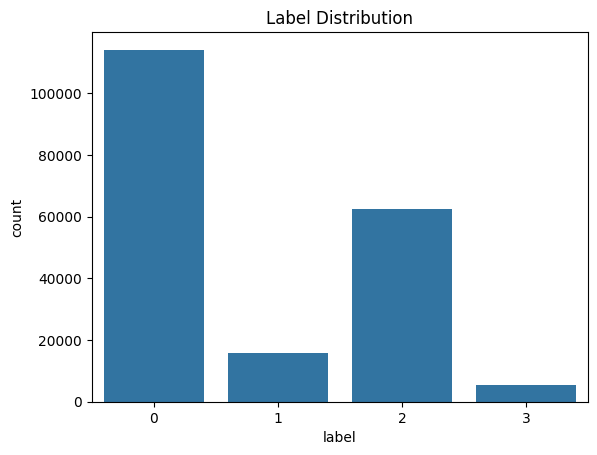

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label", data=train)
plt.title("Label Distribution")
plt.show()

***Insight:***
`From the countplot and proportions, I observed that the dataset is highly imbalanced. Label 0 alone contributes around 57%, while label 3 has less than 3% of the data. This imbalance can significantly affect model performance.`

### Text Analysis

In [131]:
df = train.copy()
df2 = test.copy()

In [132]:
df["comment"].isna().sum()

np.int64(1)

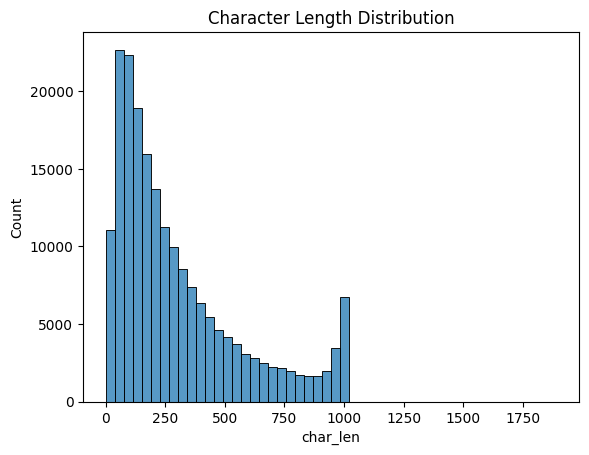

In [133]:
## Text Length Distribution
df["char_len"] = df["comment"].fillna("").apply(len)

sns.histplot(df["char_len"], bins=50)
plt.title("Character Length Distribution")
plt.show()

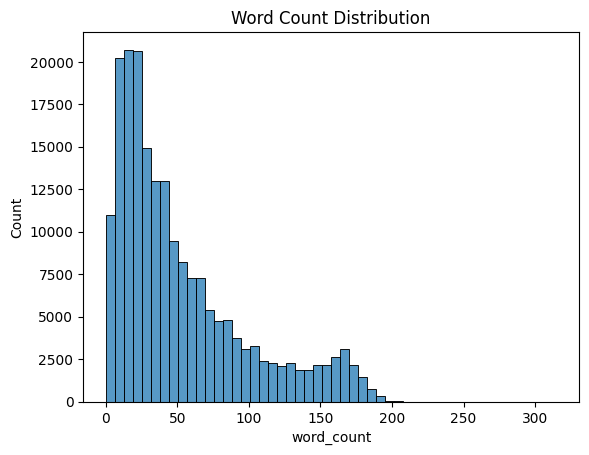

In [134]:
## Word Count Distribution
df["word_count"] = df["comment"].fillna("").apply(lambda x: len(x.split()))

sns.histplot(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

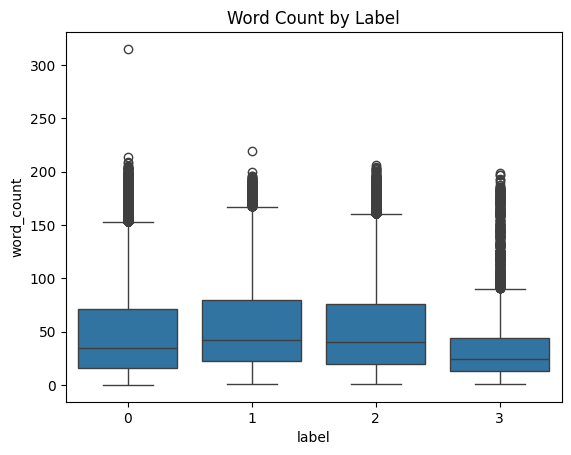

In [135]:
## Compare by label
sns.boxplot(x="label", y="word_count", data=df)
plt.title("Word Count by Label")
plt.show()

***Insights:***
1. The distribution is right-skewed, indicating most comments are short while a few are very long.
2. Most comments likely < 200–300 characters. Some comments go near 1000 characters
3. Most comments are short, with a small number of long comments acting as outliers (Right skewed, Most comments around 10-50 words, few are ~200 words).
4. Outliers may affect model performance and may need handling.
5. Although there is some variation, the overlap suggests that word count alone is not sufficient for classification.

### Emoticon Analysis

#### Create total_emoticons:

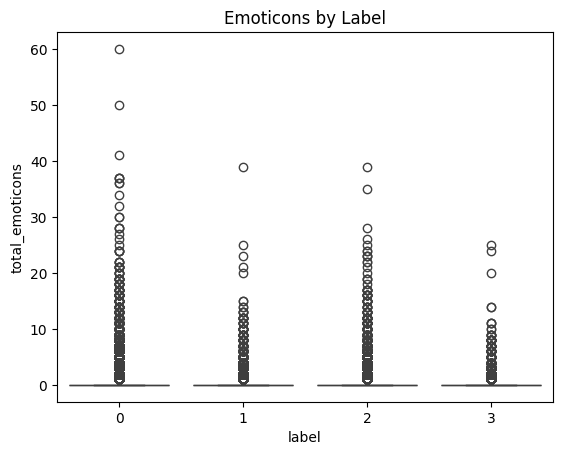

In [136]:
df["total_emoticons"] = (df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"])

sns.boxplot(x="label", y="total_emoticons", data=df)
plt.title("Emoticons by Label")
plt.show()

### Engagement Analysis

<Axes: xlabel='upvote', ylabel='Count'>

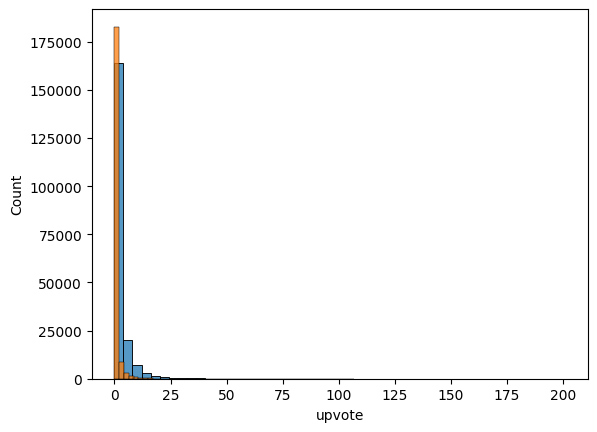

In [137]:
## Distribution
sns.histplot(df["upvote"], bins=50)
sns.histplot(df["downvote"], bins=50)

***Insight:***
1. Most comments do not contain emoticons (means 0).
2. There are extreme cases where emoticons are heavily used.
3. While emoticons provide some signal, the distributions overlap significantly, so they may not be a strong standalone predictor.

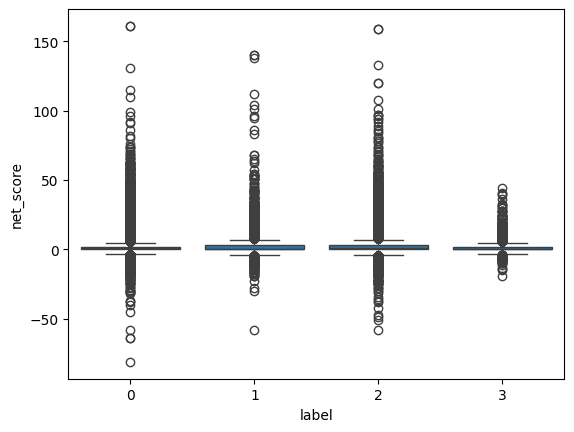

In [138]:
# Net score
df["net_score"] = df["upvote"] - df["downvote"]

sns.boxplot(x="label", y="net_score", data=df)
plt.show()

***Insghts:***
1. User engagement is highly skewed, with most comments receiving low interaction and a few receiving high attention.
2. Net score shows variability across categories, indicating that user engagement may provide useful signal for classification.
3. Highly engaged comments may be more controversial or informative, influencing classification.
4. Low engagement comments may lack sufficient signal, making classification harder.
5. Outliers in engagement may need normalization or log transformation.

### Hidden Features (if_1, if_2) analysis

In [139]:
df[["if_1", "if_2"]].describe()

,if_1,if_2
count,198000.000000,198000.000000
mean,1.906152,7.956212
std,25.635752,14.839464
min,0.000000,3.000000
25%,0.000000,4.000000
50%,0.000000,6.000000
75%,4.000000,10.000000
max,1860.000000,1833.000000


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


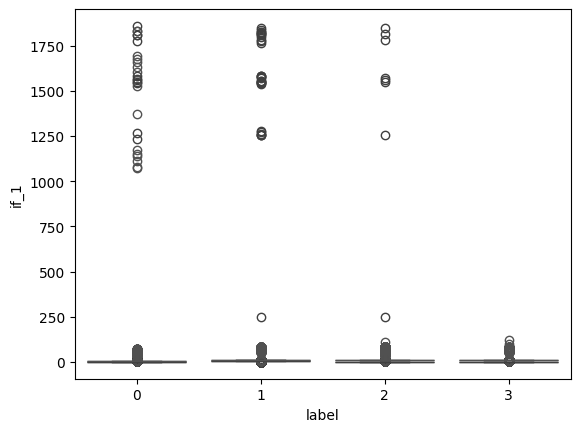

In [140]:
## Visualize by label

print(sns.boxplot(x="label", y="if_1", data=df))
print(sns.boxplot(x="label", y="if_2", data=df))

***Inights:***
1. These features appear to be internal signals generated by the platform. Their exact meaning is unknown, but they may encode useful patterns for classification.
2. Both features are highly(right) skewed with most values concentrated near zero and a few extreme outliers.
3. The large gap between median and maximum indicates the presence of extreme outliers, which may affect model performance.
4. A large portion of data has zero values, so do sparsity in this feature.
5. Due to extreme outliers, I can apply log transformation or clipping to stabilize the feature distribution.

In [141]:
df["if_1"] = np.log1p(df["if_1"])
df["if_2"] = np.log1p(df["if_2"])
df2["if_1"] = np.log1p(df2["if_1"])
df2["if_2"] = np.log1p(df2["if_2"])

In [142]:
## Check missingness:

df[["race", "religion", "gender", "disability"]].isnull().sum()

race          145423
religion      145423
gender        145423
disability         0
dtype: int64

In [143]:
df["race"].value_counts(dropna=False)

race
NaN       145423
none       39682
white       5486
black       3869
other       1654
asian       1263
latino       623
Name: count, dtype: int64

***Insights:***

1. The features race, religion, and gender have a very high percentage of missing values, around 70%, which makes them sparse and potentially unreliable.
2. The race feature is highly imbalanced, with most entries having no detected identity and only a small fraction belonging to specific group

In [144]:
## Cross-tab

pd.crosstab(df["race"], df["label"])

label,0,1,2,3
race,,,,
asian,570,364,305,24
black,608,2679,555,27
latino,274,200,143,6
none,20606,6138,11973,965
other,676,489,453,36
white,923,3338,1165,60


***Insights:***

Since these are sensitive attributes, using them directly may introduce bias in the model. Therefore, careful consideration is required when including them.

In [145]:
## Convert datetime:

df["created_date"] = pd.to_datetime(df["created_date"])

df["month"] = df["created_date"].dt.month
df["hour"] = df["created_date"].dt.hour

<Axes: xlabel='month', ylabel='count'>

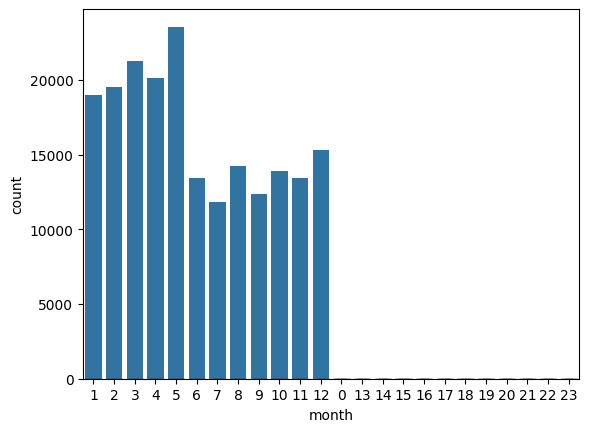

In [146]:
sns.countplot(x="month", data=df)
sns.boxplot(x="hour", y="label", data=df)

***Insights:***
1. I converted the timestamp column into datetime format to enable extraction of temporal features.
2. I analyzed how comment categories vary across different hours of the day.

### Thead analysis

In [147]:
df["post_id"].nunique()

52

In [148]:
df.groupby("post_id").size().describe()

count       52.000000
mean      3807.692308
std      11799.842188
min          1.000000
25%         10.000000
50%         27.500000
75%        243.750000
max      69529.000000
dtype: float64

***Insights:***
1. The number of comments per post is highly skewed, with a few posts having extremely high engagement.
2. Since multiple comments belong to the same post, there is a risk of data leakage if the same post appears in both training and validation sets

### Clean text feature

In [149]:
import re

def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"http\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"#\w+", " HASHTAG ", text)
    
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    
    return text

In [150]:
df["comment"] = df["comment"].fillna("")
df2["comment"] = df2["comment"].fillna("")
df["comment"] = df["comment"].apply(clean_text)
df2["comment"] = df2["comment"].apply(clean_text)

***Insights:***
1. I handled missing text values and applied preprocessing to clean and normalize the comments before feature extraction.
2. For text preprocessing, I cleaned the comments by normalizing case, replacing URLs, mentions, and hashtags with tokens, and reducing repeated characters. This helps reduce noise and improve model performance

### Correlation Matrix (Numeric columns Only)

<Axes: >

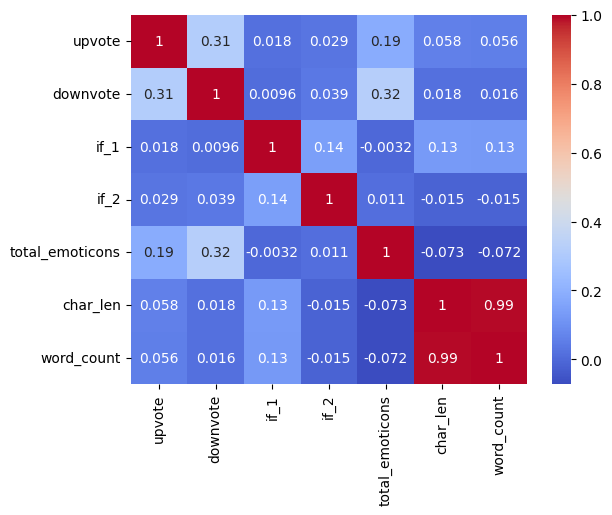

In [151]:
numeric_cols = ["upvote", "downvote", "if_1", "if_2", "total_emoticons", "char_len", "word_count"]

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")

***Insights:***
1. Character length and word count are highly correlated since both measure text size. This introduces multicollinearity, which may be redundant for some models.
2. Upvotes and downvotes show moderate positive correlation, indicating that highly visible or controversial comments tend to receive both types of engagement.
3. The hidden features show low correlation with other variables, suggesting they capture independent information that may still be useful for the model.
4. Emoticon usage appears to be weakly correlated with other features, indicating it provides a distinct signal.
5. `Highly correlated features can increase model complexity without adding new information.`
6. `Low correlation features are valuable because they introduce new information into the model.`

### Check Train vs Test Distribution Shift

**Compare distributions**

In [152]:
df["char_len"].mean(), test["comment"].fillna("").apply(len).mean()

(np.float64(302.90936363636365), np.float64(302.7424607843137))

In [153]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'char_len', 'word_count',
       'total_emoticons', 'net_score', 'month', 'hour'],
      dtype='object')

In [154]:
df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,gender,disability,comment,label,char_len,word_count,total_emoticons,net_score,month,hour
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0.0,2.397895,NaN,...,NaN,False,she might be a bright spot for a party keou on...,2,118,20,0,-1,1,8
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0.0,1.609438,NaN,...,NaN,False,"under alaska law, a non-tribal member is not b...",0,644,110,0,6,3,21
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0.0,2.397895,NaN,...,NaN,False,in the future please spare me your strawman dr...,2,751,133,2,0,4,20
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0.0,2.397895,NaN,...,NaN,False,"ps: that should have been ""rot"" instead of ""co...",2,91,15,0,5,5,22
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0.0,2.397895,NaN,...,NaN,False,"today, the confederate flag..tomorrow, the naz...",2,254,40,0,0,9,23


## Train and Validation Split

In [155]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Feature engineering

In [156]:
import pandas as pd
import numpy as np

def feature_engineering(df):
    df = df.copy()

    # Date features
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

    df["day"] = df["created_date"].dt.day
    df["month"] = df["created_date"].dt.month
    df["year"] = df["created_date"].dt.year
    df["hour"] = df["created_date"].dt.hour
    df["is_weekend"] = df["created_date"].dt.weekday.isin([5,6]).astype(int)

    df[["day","month","year","hour"]] = df[["day","month","year","hour"]].fillna(0)

    # Text features
    df["comment"] = df["comment"].fillna("")
    df["char_len"] = df["comment"].str.len()
    df["word_count"] = df["comment"].apply(lambda x: len(x.split()))

    df["avg_word_length"] = df["char_len"] / df["word_count"].replace(0,1)
    df["long_comment"] = (df["word_count"] > 100).astype(int)

    # Emoticon features
    df["total_emoticons"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]
    df["emoticon_density"] = df["total_emoticons"] / (df["word_count"] + 1)

    # Vote features
    df["net_score"] = df["upvote"] - df["downvote"]
    df["total_votes"] = df["upvote"] + df["downvote"]
    df["vote_ratio"] = df["upvote"] / (df["downvote"] + 1)

    # Interaction features
    df["engagement_score"] = np.log1p(df["total_votes"]) * np.log1p(df["word_count"] + 1)
    df["emoticon_vote_interaction"] = df["total_emoticons"] * df["total_votes"]

    # Hidden features (log transform)
    df["if_1"] = np.log1p(df["if_1"])
    df["if_2"] = np.log1p(df["if_2"])

    # Post-level feature
    if "post_id" in df.columns:
        df["post_comment_count"] = df.groupby("post_id")["post_id"].transform("count")

    # Boolean conversion
    if "disability" in df.columns:
        df["disability"] = df["disability"].astype(int)

    # Fill missing categorical values
    for col in ["race", "religion", "gender"]:
        if col in df.columns:
            df[col] = df[col].fillna("unknown")

    # Drop columns
    drop_cols = ["created_date"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df

In [157]:
X_train = feature_engineering(X_train)
X_val = feature_engineering(X_val)
test_df = feature_engineering(df2)

In [158]:
print(list(X_train.columns)) 
print(list(test_df.columns))

['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'char_len', 'word_count', 'total_emoticons', 'net_score', 'month', 'hour', 'day', 'year', 'is_weekend', 'avg_word_length', 'long_comment', 'emoticon_density', 'total_votes', 'vote_ratio', 'engagement_score', 'emoticon_vote_interaction', 'post_comment_count']
['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'day', 'month', 'year', 'hour', 'is_weekend', 'char_len', 'word_count', 'avg_word_length', 'long_comment', 'total_emoticons', 'emoticon_density', 'net_score', 'total_votes', 'vote_ratio', 'engagement_score', 'emoticon_vote_interaction', 'post_comment_count']


In [159]:
## Clean INF before preprocessing pipeline

def clean_infinite_values(df):
    df = df.replace([np.inf, -np.inf], np.nan)    ## For safety purpose, Although we avoided zero division
    return df

X_train = clean_infinite_values(X_train)
X_val = clean_infinite_values(X_val)
test_df = clean_infinite_values(test_df)

In [160]:
### Safe log transform
def safe_log1p(x):
    return np.log1p(np.clip(x, a_min=0, a_max=1e6))

In [162]:
X_train.shape, X_val.shape, test_df.shape, y_train.shape, y_val.shape

((158400, 30), (39600, 30), (102000, 30), (158400,), (39600,))

In [163]:
X_val.sample(5)

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,...,year,is_weekend,avg_word_length,long_comment,emoticon_density,total_votes,vote_ratio,engagement_score,emoticon_vote_interaction,post_comment_count
124739,31,0,0,0,0,0,0.0,1.223156,unknown,unknown,...,2023,1,5.343750,0,0.00,0,0.0,0.000000,0,3422
169116,120,0,0,0,2,1,0.0,1.080418,unknown,unknown,...,2024,0,6.445652,0,0.00,3,1.0,6.298344,0,4833
139882,72,1,1,0,0,5,0.0,1.223156,unknown,unknown,...,2023,0,5.666667,0,0.05,5,0.0,6.653828,10,13931
120013,39,0,0,0,1,0,0.0,0.959135,unknown,unknown,...,2022,0,5.000000,0,0.00,1,1.0,1.523000,0,8169
152636,73,0,0,0,0,0,0.0,0.959135,unknown,unknown,...,2024,0,5.386139,1,0.00,0,0.0,0.000000,0,2963


In [174]:
samples = X_val[["comment"]].sample(n=5)
display(samples)

for i, comment in enumerate(samples["comment"], start=1):
    print(f"Example {i}:\n{comment}\n")

,comment
181784,the us is an international bully and needs its...
21956,can trupm stop putting his foot in his mouth a...
78841,good luck with my-way-or-the-highway stevenson...
114729,because he thought dusg they were attending se...
173807,"why is it, that the native corporation have be..."


Example 1:
the us is an international bully and needs its physical threat.  of course, the us will not seriously consider disarming.  we are more concerned in making sure that other nations do not acqiure our abilities to kill.

Example 2:
can trupm stop putting his foot in his mouth and stay out of it?

Example 3:
good luck with my-way-or-the-highway stevenson there's a reason she's no longer in jeffco.

Example 4:
because he thought dusg they were attending services there. he posted threats to his mother in law that very morning. he was after them, and their friends. a nut-job that should have never been able to own a firearm. but the nra, congress, texas and the air force made sure it was an option available to him. reaping what you have sown.

Example 5:
why is it, that the native corporation have become million dollar entities? those "jokers" must be doing something right to offer dividends year after year..  put that in your hat and eat it robert.



## Preprocessing

In [ ]:
num_features = [
    "emoticon_1","emoticon_2","emoticon_3",
    "upvote","downvote","if_1","if_2",
    "word_count","total_emoticons",
    "net_score","month","hour",
    "avg_word_length","total_votes","vote_ratio",
    "emoticon_density","engagement_score",
    "emoticon_vote_interaction"
]

cat_features = [
    "race","religion","gender","disability",
    "is_weekend","long_comment"
]

text_feature = "comment"

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# ## Numerical columns pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(safe_log1p)),
    ("clipper", FunctionTransformer()),
    ("scaler", StandardScaler())
])

## Categorical columns pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="none")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))
])


def flatten_text(x):
    return x.ravel()

# ## Text column pipeline
# from sklearn.pipeline import FeatureUnion

# word_tfidf = TfidfVectorizer(
#     stop_words="english",
#     ngram_range=(1, 2),
#     max_features=20000,
#     min_df=5
# )

# char_tfidf = TfidfVectorizer(
#     analyzer="char",
#     ngram_range=(3, 5),
#     max_features=20000
# )

# text_pipeline = Pipeline([
#     ("imputer", SimpleImputer(
#         strategy="constant",
#         fill_value=""
#     )),
#     ("flatten", FunctionTransformer(
#         flatten_text,
#         validate=False
#     )),
#     ("tfidf", FeatureUnion([
#         ("word", word_tfidf),
#         ("char", char_tfidf)
#     ]))
# ])

In [ ]:
### Train models only on text feature for deployment

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score


word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=3,
    sublinear_tf=True,
    stop_words="english"
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=15000,
    min_df=3,
    sublinear_tf=True
)


text_model = Pipeline([
    (
        "tfidf",
        FeatureUnion([
            ("word", word_tfidf),
            ("char", char_tfidf)
        ])
    ),
    (
        "model",
        SGDClassifier(
            loss="log_loss",
            alpha=5e-6,
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])



### Combining all features and transform it

In [ ]:
# preprocessor = ColumnTransformer([
#     ("num", num_pipeline, num_features),
#     ("cat", cat_pipeline, cat_features),
#     ("text", text_pipeline, ["comment"])
# ])

## Model Building and Training 

In [ ]:
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
# !pip install xgboost lightgbm catboost

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import RidgeClassifier
from catboost import CatBoostClassifier

In [ ]:
models = {

    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        C=1.0,
        n_jobs=-1,
        class_weight="balanced"
    ),
    
    "SGDClassifier": SGDClassifier(
        loss="log_loss",
        alpha=5e-6,
        max_iter=2000,
        class_weight="balanced"
    ),
    
    "RidgeClassifier": RidgeClassifier(
        class_weight="balanced"
    ),

    # "LightGBM": LGBMClassifier(
    #     n_estimators=600,
    #     learning_rate=0.03,
    #     num_leaves=63,
    #     min_child_samples=50,
    #     subsample=0.7,
    #     colsample_bytree=0.7,
    #     reg_alpha=0.3,
    #     reg_lambda=0.3,
    #     class_weight="balanced",
    #     n_jobs=-1
    # ),

    # "LinearSVC": LinearSVC(
    #     C=1.0,
    #     max_iter=8000
    # ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        n_jobs=-1,
        random_state=42
    ),
    
    # "ExtraTrees": ExtraTreesClassifier(
    #     n_estimators=300,
    #     max_depth=30,
    #     n_jobs=-1,
    #     random_state=42
    # ),

    # "MultiominalNB": MultinomialNB(    ### Works only if TF-IDF output is non-negative.
    #     alpha=0.1
    # ),
    
    # "XGBoost": XGBClassifier(
    #     n_estimators=300,
    #     max_depth=6,
    #     learning_rate=0.05,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     tree_method="hist",
    #     eval_metric="mlogloss",
    #     n_jobs=-1
    # ),
    
    # "CatBoost": CatBoostClassifier(
    #     iterations=300,
    #     learning_rate=0.05,
    #     depth=6,
    #     verbose=0
    # ),

    # "GradientBoosting": GradientBoostingClassifier(
    #     n_estimators=150,
    #     learning_rate=0.1
    # ),

    # "KNN": KNeighborsClassifier(   ### perform poorly on tf-idf sparse data
    #     n_neighbors=7
    # ),

    # "DecisionTree": DecisionTreeClassifier(     ##### perform poorly on tf-idf sparse data
    #     max_depth=20,
    #     random_state=42
    # )
}

## Train and Evaluate the models

In [ ]:
# from sklearn.metrics import f1_score
# from sklearn.pipeline import Pipeline
# import time

# results = []

# for name, model in models.items():

#     pipe = Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", model)
#     ])

#     print(f"Training {name}...")
#     start = time.time()

#     pipe.fit(X_train, y_train)

#     # Predictions
#     train_pred = pipe.predict(X_train)
#     val_pred = pipe.predict(X_val)

#     # Scores
#     train_f1 = f1_score(y_train, train_pred, average="macro")
#     val_f1 = f1_score(y_val, val_pred, average="macro")
#     gap = train_f1 - val_f1

#     # Probabilities (for ensemble)
#     if hasattr(pipe, "predict_proba"):
#         val_proba = pipe.predict_proba(X_val)
#     else:
#         val_proba = None

#     elapsed = time.time() - start

#     results.append((name, train_f1, val_f1, gap, elapsed, pipe, val_proba))

#     print(f"{name}")
#     print("Train F1:", train_f1)
#     print("Validation F1:", val_f1)
#     print("Overfit Gap:", gap)
#     print("Time:", round(elapsed, 2), "sec")
#     print("-"*40)

## Compare all models

In [ ]:
# import pandas as pd

# results_df = pd.DataFrame(
#     [(r[0], r[1], r[2], r[3], r[4]) for r in results],
#     columns=["Model", "Train_F1", "Val_F1", "Gap", "Time"]
# ).sort_values("Val_F1", ascending=False)

# print(results_df)

## Choose best model and retrieve in pipeline 

In [ ]:
# best_model_name = results_df.iloc[0]["Model"]

# print("Best Model:", best_model_name)

# best_pipeline = None

# for r in results:
#     if r[0] == best_model_name:
#         best_pipeline = r[3]

In [ ]:
# top_models = sorted(results, key=lambda x: x[2], reverse=True)[:3]

# preds = []
# weights = [0.6, 0.2, 0.2]

# for i, (_, _, _, _, _, model, proba) in enumerate(top_models):
#     if proba is not None:
#         preds.append(proba * weights[i])

# ensemble_pred = sum(preds)
# final_pred = ensemble_pred.argmax(axis=1)

# from sklearn.metrics import f1_score
# f1_score(y_val, final_pred, average="macro")

## HyperParameter tuning with Cross-Validation

In [ ]:
## Smarter parameters spaces
# param_spaces = {

#     "LogisticRegression": {
#         "model__C": [0.5, 1, 2, 3, 5],
#         "model__solver": ["lbfgs"],
#         "model__max_iter": [2000, 3000],
#         "model__class_weight": ["balanced"]
#     },

#     "SGDClassifier": {
#         "model__loss": ["log_loss"],
#         "model__alpha": [1e-6, 5e-6, 1e-5, 5e-5],
#         "model__penalty": ["l2", "elasticnet"],
#         "model__max_iter": [1500, 2000],
#         "model__learning_rate": ["optimal"],
#         "model__class_weight": ["balanced"]
#     }

    # "LightGBM": {
    #     "model__num_leaves": [31, 63],
    #     "model__learning_rate": [0.03, 0.05],
    #     "model__min_child_samples": [20, 50],
    #     "model__subsample": [0.7, 0.8],
    #     "model__reg_alpha": [0, 0.1, 0.3],
    #     "model__reg_lambda": [0, 0.1, 0.3]
    # }
# }

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# def tune_model(pipe, model_name):

#     params = param_spaces.get(model_name)

#     search = RandomizedSearchCV(
#         pipe,
#         params,
#         n_iter=8,   # time optimized, but effective
#         scoring="f1_macro",
#         cv=cv,
#         n_jobs=-1,
#         verbose=2,
#         random_state=42,
#         error_score="raise"
#     )

#     search.fit(X_train, y_train)

#     print(f"\nBest params for {model_name}:")
#     print(search.best_params_)
#     print(f"Best CV score: {search.best_score_}")

#     return search.best_estimator_, search.best_score_

In [ ]:
# ## Prepare CV strategy - reduce cv fold 
# from sklearn.model_selection import StratifiedKFold

# cv = StratifiedKFold(
#     n_splits=3,   # instead of 5
#     shuffle=True,
#     random_state=42
# )

### Extract the best three model pipeline

In [ ]:
# sort by validation score
# results_sorted = sorted(results, key=lambda x: x[2], reverse=True)

# # Correct unpacking
# name1, train1, val1, gap1, time1, pipe1, proba1 = results_sorted[0]
# name2, train2, val2, gap2, time2, pipe2, proba2 = results_sorted[1]
# name3, train3, val3, gap3, time3, pipe3, proba3 = results_sorted[2]

### Preprocess again for RandomizedSearchCV

`Because our models are already preprocessed and trained, but RandomizedSeachCV expects fresh pipeline`

In [ ]:
# pipelines = {
#     "LogisticRegression": Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", LogisticRegression())
#     ]),

#     "SGDClassifier": Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", SGDClassifier())
#     ])
# }

### Tune Top three models

In [ ]:
# tuned_results = []

# for model_name, pipe in pipelines.items():
#     print(f"\n Tuning {model_name}...")
#     best_est, score = tune_model(pipe, model_name)
#     tuned_results.append((model_name, score, best_est))

## Comapare tuned models

In [ ]:
# comparison = []

# for name, train_f1, val_f1, *_ in results:
#     if name in ["LogisticRegression", "SGDClassifier"]:
#         tuned_score = next((r[1] for r in tuned_results if r[0] == name), None)
#         improvement = tuned_score - val_f1 if tuned_score else None
#         comparison.append((name, val_f1, tuned_score, improvement))


# comparison_df = pd.DataFrame(
#     comparison,
#     columns=["Model", "Before_Tuning", "After_Tuning", "Improvement"]
# )

# print(comparison_df)

### Use Tuned models for ensemble

In [ ]:
# # sort tuned models
# tuned_sorted = sorted(tuned_results, key=lambda x: x[1], reverse=True)

# log_model = next(r[2] for r in tuned_results if r[0] == "LogisticRegression")
# sgd_model = next(r[2] for r in tuned_results if r[0] == "SGDClassifier")

# # LightGBM from previous results
# lgb_model = next(r[5] for r in results if r[0] == "LightGBM")

# # weighted ensemble
# pred = (
#     0.4 * log_model.predict_proba(X_val) +
#     0.3 * sgd_model.predict_proba(X_val) +
#     0.3 * lgb_model.predict_proba(X_val)
# )

# final_pred = pred.argmax(axis=1)

# from sklearn.metrics import f1_score
# print("Final Ensemble F1:", f1_score(y_val, final_pred, average="macro"))

## Train best model on full dataset

In [ ]:
# test_df = test_df[X_train.columns]

In [ ]:
# X_full = pd.concat([X_train, X_val])
# y_full = pd.concat([y_train, y_val])

# final_models = []

# for name, _, _, _, _, pipe, _ in top_models:
#     print(f"Refitting {name} on full data...")
#     pipe.fit(X_full, y_full)
#     final_models.append(pipe)

In [ ]:
###### With training on full dataset
# preds = []
# weights = [0.6, 0.2, 0.2]

# for i, model in enumerate(final_models):
#     proba = model.predict_proba(test_df)
#     preds.append(proba * weights[i])

# final_pred = sum(preds).argmax(axis=1)


### Without traing on full dataset
# preds = []
# weights = [0.6, 0.2, 0.2]

# for i, (_, _, _, _, _, model, _) in enumerate(top_models):
#     proba = model.predict_proba(test_df)
#     preds.append(proba * weights[i])

# final_pred = sum(preds).argmax(axis=1)

In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import SGDClassifier

# sgd_pipeline = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", SGDClassifier(
#         loss="log_loss",
#         alpha=5e-6,
#         max_iter=2000,
#         class_weight="balanced",
#         random_state=42
#     ))
# ])

# sgd_pipeline.fit(X_train, y_train)

### fit only on text feature
text_model.fit(
    X_train["comment"].fillna(""),
    y_train
)

val_pred = text_model.predict(
    X_val["comment"].fillna("")
)

score = f1_score(
    y_val,
    val_pred,
    average="macro"
)

print("Text-only Macro F1:", score)

In [ ]:
# from sklearn.metrics import f1_score

# val_pred = sgd_pipeline.predict(X_val)

# print(
#     "Validation Macro F1:",
#     f1_score(y_val, val_pred, average="macro")
# )


import pandas as pd

print(
    pd.Series(val_pred)
      .value_counts(normalize=True)
      .sort_index()
)

In [ ]:
# import os
# import joblib

# os.makedirs("models", exist_ok=True)

# joblib.dump(
#     sgd_pipeline,
#     "models/sgd_classifier_pipeline2.joblib",
#     compress=3
# )


# #### Verify both models are same score or not.
# import numpy as np
# from sklearn.metrics import f1_score

# original_pred = sgd_pipeline.predict(X_val)
# loaded_pred = loaded_pipeline.predict(X_val)

# print(
#     "Identical predictions:",
#     np.array_equal(original_pred, loaded_pred)
# )

# print(
#     "Original F1:",
#     f1_score(y_val, original_pred, average="macro")
# )

# print(
#     "Loaded F1:",
#     f1_score(y_val, loaded_pred, average="macro")
# )


#### Try some sample
tests = [
    "hello",
    "I completely disagree with this!",
    "This is a much longer comment explaining my opinion...",
    "😂😂😂",
]

for text in tests:
    proba = text_model.predict_proba([text])[0]
    pred = text_model.classes_[proba.argmax()]

    print(text)
    print("Prediction:", pred)
    print("Probabilities:", proba)
    print()

In [ ]:
# import os
# import cloudpickle

# os.makedirs("models", exist_ok=True)

# # Save the existing fitted pipeline
# model_path = "models/sgd_classifier_pipeline.pkl"

# with open(model_path, "wb") as f:
#     cloudpickle.dump(sgd_pipeline, f)

# # Verify that it loads
# with open(model_path, "rb") as f:
#     loaded_pipeline = cloudpickle.load(f)

# print("Pipeline saved and loaded successfully!")

In [ ]:
### save text only model
import cloudpickle
import os

os.makedirs("models", exist_ok=True)

with open(
    "models/text_only_sgd_pipeline.pkl",
    "wb"
) as f:
    cloudpickle.dump(text_model, f)


##### Verify text only model
with open(
    "models/text_only_sgd_pipeline.pkl",
    "rb"
) as f:
    loaded_text_model = cloudpickle.load(f)

original = text_model.predict(
    X_val["comment"].fillna("")
)

loaded = loaded_text_model.predict(
    X_val["comment"].fillna("")
)

import numpy as np

print(np.array_equal(original, loaded))

In [ ]:
### Check dependencies versions for deployment
import sklearn
import numpy
import scipy
import cloudpickle

print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("cloudpickle:", cloudpickle.__version__)

import os

size_mb = os.path.getsize(
    # "models/sgd_classifier_pipeline.pkl",
    "models/text_only_sgd_pipeline.pkl"
) / (1024 ** 2)

print(f"Model size: {size_mb:.2f} MB")

In [ ]:
print(
    loaded_pipeline
        .named_steps["preprocessor"]
        .feature_names_in_
)

for name, transformer, columns in (
    loaded_pipeline
        .named_steps["preprocessor"]
        .transformers_
):
    print(name, ":", columns)

print("Classes:", loaded_pipeline.classes_)

In [ ]:
import pandas as pd
import numpy as np

# Predictions on REAL validation features
real_proba = loaded_pipeline.predict_proba(X_val)
real_pred = loaded_pipeline.classes_[np.argmax(real_proba, axis=1)]

print("REAL VALIDATION PREDICTION DISTRIBUTION")
print(
    pd.Series(real_pred)
      .value_counts(normalize=True)
      .sort_index()
)

print("\nREAL VALIDATION MEAN PROBABILITIES")
print(
    pd.Series(
        real_proba.mean(axis=0),
        index=loaded_pipeline.classes_
    )
)

In [ ]:
print("\nTRUE VALIDATION DISTRIBUTION")
print(
    pd.Series(y_val)
      .value_counts(normalize=True)
      .sort_index()
)

In [ ]:
hidden_defaults = {
    "if_1": float(X_train["if_1"].median()),
    "if_2": float(X_train["if_2"].median()),
    "month": int(X_train["month"].median()),
    "hour": int(X_train["hour"].median()),
    "is_weekend": int(X_train["is_weekend"].mode()[0]),
}

categorical_defaults = {
    "race": X_train["race"].mode()[0],
    "religion": X_train["religion"].mode()[0],
    "gender": X_train["gender"].mode()[0],
    "disability": int(X_train["disability"].mode()[0]),
}

print(hidden_defaults)
print(categorical_defaults)

In [ ]:
print(
    X_train[
        [
            "upvote",
            "downvote",
            "emoticon_1",
            "emoticon_2",
            "emoticon_3"
        ]
    ].median()
)

In [ ]:
pd.Series(final_pred).value_counts(normalize=True)

In [ ]:
# # test_predictions = best_pipeline.predict(test_df)
# # test_predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "ID": range(1, len(final_pred) + 1),
    "label": final_pred
})

submission.to_csv("submission.csv", index=False)

In [ ]:
submission.head()

In [ ]:
submission["label"].value_counts()

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

for name, train_f1, val_f1, gap, elapsed, pipe, val_proba in results:

    filename = f"models/{name.lower()}_pipeline.joblib"

    joblib.dump(
        pipe,
        filename,
        compress=3
    )

    print(f"Saved {name} -> {filename}")

In [ ]:
for r in results:1
    name = r[0]
    pipe = r[5]

    if name == "LogisticRegression":
        joblib.dump(pipe, "logistic_regression_pipeline.joblib")
        print("Saved Logistic Regression")

In [ ]:
### Save the best model

import joblib

best_model_name = results_df.iloc[0]["Model"]

best_pipeline = None

for r in results:
    if r[0] == best_model_name:
        best_pipeline = r[5]   # fitted Pipeline
        break

joblib.dump(best_pipeline, "sgd_classifier_pipeline.joblib")

print("Saved:", best_model_name)